In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Imports and set up**

Impoting all required libraries for data handling , freature extraction , model training and evaluation

In [44]:
 # Core
import re
import string
import random
import numpy as np
import pandas as pd

# Data splitting & feature extraction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# PyTorch
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler


# Plotting (for validation loss curves, confusion matrices)
import matplotlib.pyplot as plt

**Data loading**
Loading the MasakhaNEWS dataset for the three target languages :

In [45]:
DATA_PATH = "/content/drive/MyDrive/news-dataset"

def load_language(language):
    train = pd.read_csv(f"{DATA_PATH}/{language}/train.tsv", sep="\t")
    dev   = pd.read_csv(f"{DATA_PATH}/{language}/dev.tsv",   sep="\t")
    test  = pd.read_csv(f"{DATA_PATH}/{language}/test.tsv",  sep="\t")
    return train, dev, test

eng_train, eng_dev, eng_test = load_language("eng")
xho_train, xho_dev, xho_test = load_language("xho")
sna_train, sna_dev, sna_test = load_language("sna")

print("Data loaded successfully!")
print("English train size:", len(eng_train))

Data loaded successfully!
English train size: 3309


##Text Processing
Label Encoding

Converting he categorical news topics into integer labels using labelEncoder. The encoder if fitted only on the training set to avoid data leakage

In [46]:
# 1. Create full_text
def create_full_text(df):
    return df["headline"].fillna("") + " " + df["text"].fillna("")


eng_train["full_text"] = create_full_text(eng_train)
eng_dev["full_text"]   = create_full_text(eng_dev)
eng_test["full_text"]  = create_full_text(eng_test)


# 2. Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


eng_train_text = eng_train["full_text"].apply(clean_text)
eng_dev_text   = eng_dev["full_text"].apply(clean_text)
eng_test_text  = eng_test["full_text"].apply(clean_text)


# 3. Encode the category labels
LABEL_COL = "category"

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(eng_train[LABEL_COL])
y_dev   = label_encoder.transform(eng_dev[LABEL_COL])
y_test  = label_encoder.transform(eng_test[LABEL_COL])


# Check what happened
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", len(label_encoder.classes_))

Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Number of classes: 6


##Feature Extraction -Bag-of-words
Converting the cleaned text into numerical vectors using a countVectoriser

In [47]:
# 4. Feature extraction (start with Bag-of-Words)
vectorizer = CountVectorizer(
    max_features=5000,
    min_df=3
)

X_train = vectorizer.fit_transform(eng_train_text)
X_dev   = vectorizer.transform(eng_dev_text)
X_test  = vectorizer.transform(eng_test_text)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("X_train shape:", X_train.shape)

# 5. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_dev_tensor   = torch.tensor(X_dev.toarray(),   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.toarray(),  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_dev_tensor   = torch.tensor(y_dev,   dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

print("\nTensors ready!")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

Vocabulary size: 5000
X_train shape: (3309, 5000)

Tensors ready!
X_train_tensor: torch.Size([3309, 5000])
y_train_tensor: torch.Size([3309])


##Convert to pytorch Tensors


In [48]:
def prepare_language(
    train_df,
    dev_df,
    test_df,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
):
    # 1. Create and clean full text
    train_text = (
        train_df["headline"].fillna("") + " " +
        train_df["text"].fillna("")
    ).apply(clean_text)

    dev_text = (
        dev_df["headline"].fillna("") + " " +
        dev_df["text"].fillna("")
    ).apply(clean_text)

    test_text = (
        test_df["headline"].fillna("") + " " +
        test_df["text"].fillna("")
    ).apply(clean_text)

    # 2. Encode labels
    le = LabelEncoder()

    y_train = le.fit_transform(train_df["category"])
    y_dev   = le.transform(dev_df["category"])
    y_test  = le.transform(test_df["category"])

    # 3. Choose feature extractor
    if vectorizer_type == "count":
        vectorizer = CountVectorizer(
            max_features=max_features,
            min_df=min_df
        )
    elif vectorizer_type == "tfidf":
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df
        )
    else:
        raise ValueError(
            "vectorizer_type must be 'count' or 'tfidf'"
        )

    # 4. Fit only on training data
    X_train = vectorizer.fit_transform(train_text)

    # Use the same vocabulary for dev and test
    X_dev = vectorizer.transform(dev_text)
    X_test = vectorizer.transform(test_text)

    # 5. Convert features to PyTorch tensors
    X_train_t = torch.tensor(
        X_train.toarray(), dtype=torch.float32
    )
    X_dev_t = torch.tensor(
        X_dev.toarray(), dtype=torch.float32
    )
    X_test_t = torch.tensor(
        X_test.toarray(), dtype=torch.float32
    )

    # 6. Convert labels to PyTorch tensors
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_dev_t   = torch.tensor(y_dev, dtype=torch.long)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    print(
        f"Prepared data → features: {X_train_t.shape[1]}, "
        f"classes: {len(le.classes_)}"
    )
    print(f"Classes: {list(le.classes_)}")

    return {
        "X_train": X_train_t,
        "y_train": y_train_t,
        "X_dev": X_dev_t,
        "y_dev": y_dev_t,
        "X_test": X_test_t,
        "y_test": y_test_t,
        "vectorizer": vectorizer,
        "label_encoder": le,
        "num_classes": len(le.classes_),
        "input_dim": X_train_t.shape[1]
    }

## Mutinomial Logistic Regression Model
This is the implementation of the mutlinomial logistic Regresstion

In [49]:
class MultinomialLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        """Process a batch of inputs during training (returns logits)."""
        return self.linear(x)

    def compute_probabilities(self, x):
        """Compute class probabilities for a batch of inputs."""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)

    def predict(self, x):
        """Return the predicted class indices for a batch of inputs."""
        probs = self.compute_probabilities(x)
        return torch.argmax(probs, dim=1)

##Mutinomial logistic Regression class

In [50]:
input_dim = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

model = MultinomialLogisticRegression(input_dim, num_classes)

# Quick sanity check
with torch.no_grad():
    logits = model(X_train_tensor[:5])
    probs  = model.compute_probabilities(X_train_tensor[:5])
    preds  = model.predict(X_train_tensor[:5])

print("Logits shape:", logits.shape)
print("Probs shape:", probs.shape)
print("Preds:", preds)

Logits shape: torch.Size([5, 6])
Probs shape: torch.Size([5, 6])
Preds: tensor([3, 3, 3, 3, 3])


In [51]:
import copy

def train_model(
    model,
    X_train, y_train,
    X_dev, y_dev,
    lr=0.01,
    batch_size=32,
    num_epochs=50,
    patience=5,
    verbose=True
):
    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Gradient descent optimizer
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    # Mini-batch training data
    train_dataset = TensorDataset(X_train, y_train)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Track the best validation performance
    best_val_acc = 0.0
    best_model_state = None
    epochs_without_improvement = 0

    # Store results for analysis/plots
    train_losses = []
    val_accuracies = []

    # Training loop
    for epoch in range(num_epochs):

        # ---- Training ----
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(X_batch)

            # Calculate cross-entropy loss
            loss = criterion(logits, y_batch)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            epoch_loss += loss.item()

        # Average loss for this epoch
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- Validation ----
        model.eval()

        with torch.no_grad():
            val_preds = model.predict(X_dev)

            val_acc = (
                (val_preds == y_dev)
                .float()
                .mean()
                .item()
            )

        val_accuracies.append(val_acc)

        # Print progress
        if verbose:
            print(
                f"Epoch {epoch + 1:3d} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

        # ---- Early stopping ----
        if val_acc > best_val_acc:

            best_val_acc = val_acc

            # Make a deep copy of the best weights
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                if verbose:
                    print(
                        f"Early stopping at epoch {epoch + 1}"
                    )

                break

    # Restore the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "best_val_acc": best_val_acc
    }

In [52]:
# Prepare English data with Bag-of-Words
eng_bow = prepare_language(
    eng_train, eng_dev, eng_test,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
)

Prepared data → features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']


In [53]:
# Create model
model = MultinomialLogisticRegression(
    input_dim=eng_bow["input_dim"],
    num_classes=eng_bow["num_classes"]
)

# Train
history = train_model(
    model,
    eng_bow["X_train"], eng_bow["y_train"],
    eng_bow["X_dev"],   eng_bow["y_dev"],
    lr=0.1,
    batch_size=64,
    num_epochs=100,
    patience=7,
    verbose=True
)

print(f"\nBest validation accuracy: {history['best_val_acc']:.4f}")

Epoch   1 | Train Loss: 41.1286 | Val Acc: 0.5403
Epoch   2 | Train Loss: 8.2338 | Val Acc: 0.7161
Epoch   3 | Train Loss: 5.7442 | Val Acc: 0.7479
Epoch   4 | Train Loss: 2.5669 | Val Acc: 0.6017
Epoch   5 | Train Loss: 2.6296 | Val Acc: 0.7966
Epoch   6 | Train Loss: 2.2378 | Val Acc: 0.7076
Epoch   7 | Train Loss: 1.4166 | Val Acc: 0.8390
Epoch   8 | Train Loss: 1.0327 | Val Acc: 0.8242
Epoch   9 | Train Loss: 0.8199 | Val Acc: 0.7797
Epoch  10 | Train Loss: 0.8567 | Val Acc: 0.8453
Epoch  11 | Train Loss: 0.9110 | Val Acc: 0.8538
Epoch  12 | Train Loss: 0.3458 | Val Acc: 0.8623
Epoch  13 | Train Loss: 0.6190 | Val Acc: 0.8623
Epoch  14 | Train Loss: 0.2877 | Val Acc: 0.8517
Epoch  15 | Train Loss: 0.2134 | Val Acc: 0.8581
Epoch  16 | Train Loss: 0.1126 | Val Acc: 0.8708
Epoch  17 | Train Loss: 0.1384 | Val Acc: 0.8644
Epoch  18 | Train Loss: 0.0630 | Val Acc: 0.8644
Epoch  19 | Train Loss: 0.0509 | Val Acc: 0.8729
Epoch  20 | Train Loss: 0.0432 | Val Acc: 0.8708
Epoch  21 | Train L

In [54]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X, y, label_encoder, title="Test"):
    model.eval()
    with torch.no_grad():
        preds = model.predict(X).cpu().numpy()

    y_true = y.cpu().numpy()

    acc = accuracy_score(y_true, preds)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, preds, average="micro")
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average="macro")

    print(f"\n===== {title} Results =====")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision (micro): {precision_micro:.4f} | (macro): {precision_macro:.4f}")
    print(f"Recall    (micro): {recall_micro:.4f} | (macro): {recall_macro:.4f}")
    print(f"F1        (micro): {f1_micro:.4f} | (macro): {f1_macro:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {title}")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision_micro": precision_micro, "precision_macro": precision_macro,
        "recall_micro": recall_micro, "recall_macro": recall_macro,
        "f1_micro": f1_micro, "f1_macro": f1_macro
    }


===== English BoW Test Results =====
Accuracy       : 0.8935
Precision (micro): 0.8935 | (macro): 0.8890
Recall    (micro): 0.8935 | (macro): 0.8888
F1        (micro): 0.8935 | (macro): 0.8884


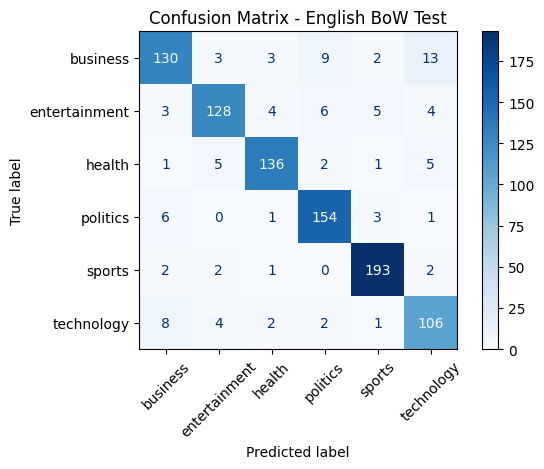

In [55]:
test_results = evaluate_model(
    model,
    eng_bow["X_test"],
    eng_bow["y_test"],
    eng_bow["label_encoder"],
    title="English BoW Test"
)

In [56]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Random seed set to 42")

Random seed set to 42


##Baseline experiments: 3 languages  x 2 feature types

##Baseline results summary


Training ENG with COUNT
Prepared data → features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

===== ENG COUNT Test Results =====
Accuracy       : 0.8945
Precision (micro): 0.8945 | (macro): 0.8897
Recall    (micro): 0.8945 | (macro): 0.8897
F1        (micro): 0.8945 | (macro): 0.8895


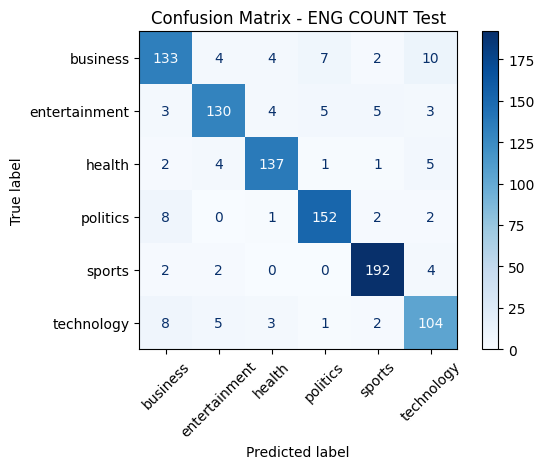


Training ENG with TFIDF
Prepared data → features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

===== ENG TFIDF Test Results =====
Accuracy       : 0.8460
Precision (micro): 0.8460 | (macro): 0.8533
Recall    (micro): 0.8460 | (macro): 0.8334
F1        (micro): 0.8460 | (macro): 0.8383


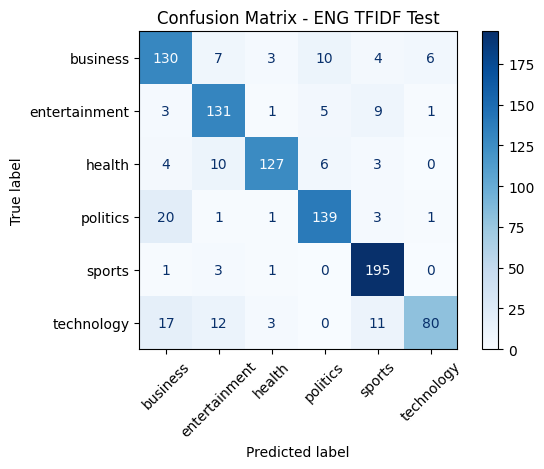


Training XHO with COUNT
Prepared data → features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']

===== XHO COUNT Test Results =====
Accuracy       : 0.8822
Precision (micro): 0.8822 | (macro): 0.8676
Recall    (micro): 0.8822 | (macro): 0.7121
F1        (micro): 0.8822 | (macro): 0.7486


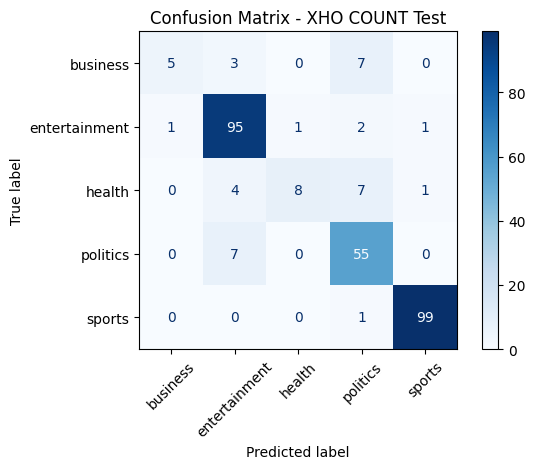


Training XHO with TFIDF
Prepared data → features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== XHO TFIDF Test Results =====
Accuracy       : 0.6667
Precision (micro): 0.6667 | (macro): 0.2828
Recall    (micro): 0.6667 | (macro): 0.3960
F1        (micro): 0.6667 | (macro): 0.3254


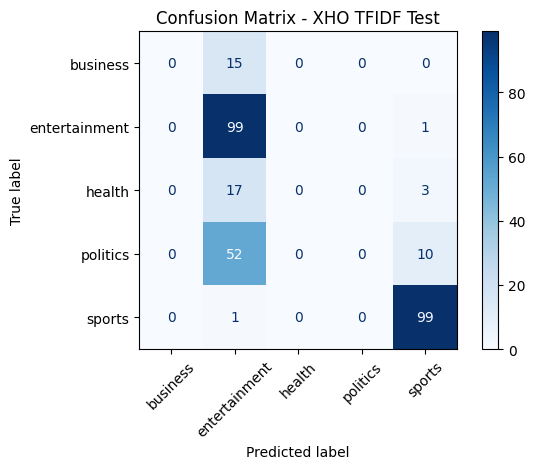


Training SNA with COUNT
Prepared data → features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']

===== SNA COUNT Test Results =====
Accuracy       : 0.9295
Precision (micro): 0.9295 | (macro): 0.9340
Recall    (micro): 0.9295 | (macro): 0.9297
F1        (micro): 0.9295 | (macro): 0.9311


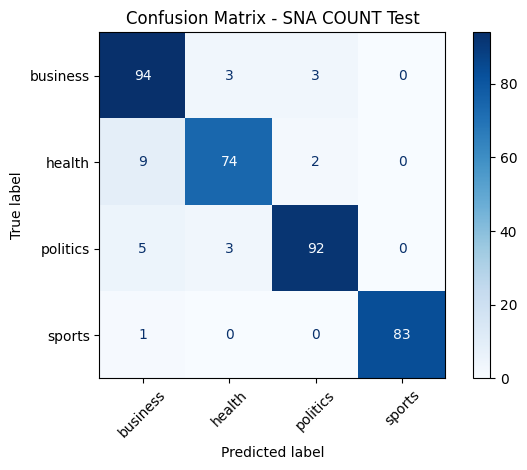


Training SNA with TFIDF
Prepared data → features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']

===== SNA TFIDF Test Results =====
Accuracy       : 0.8943
Precision (micro): 0.8943 | (macro): 0.9122
Recall    (micro): 0.8943 | (macro): 0.8897
F1        (micro): 0.8943 | (macro): 0.8922


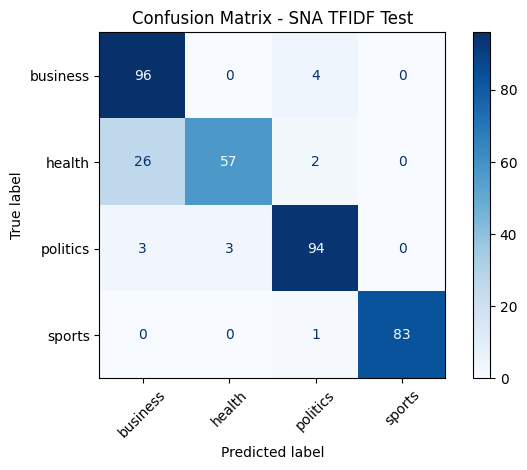



ALL baseline models finished


In [58]:
languages = {
    "eng": (eng_train, eng_dev, eng_test),
    "xho": (xho_train, xho_dev, xho_test),
    "sna": (sna_train, sna_dev, sna_test)
}

# Storing the results
baseline_results = {}

for lang_name, (train_df, dev_df, test_df) in languages.items():
    for vec_type in ["count", "tfidf"]:          # ← this line was broken

        print(f"\n{'='*60}")
        print(f"Training {lang_name.upper()} with {vec_type.upper()}")
        print(f"{'='*60}")

        # 1. Prepare data
        data = prepare_language(
            train_df, dev_df, test_df,
            max_features=5000,
            min_df=3,
            vectorizer_type=vec_type
        )

        # 2. Create model
        model = MultinomialLogisticRegression(
            input_dim=data["input_dim"],
            num_classes=data["num_classes"]
        )

        # 3. Train
        history = train_model(
            model,
            data["X_train"], data["y_train"],
            data["X_dev"],   data["y_dev"],
            lr=0.1,
            batch_size=64,
            num_epochs=100,
            patience=7,
            verbose=False
        )

        # 4. Evaluate on test set
        test_results = evaluate_model(
            model,
            data["X_test"],
            data["y_test"],
            data["label_encoder"],
            title=f"{lang_name.upper()} {vec_type.upper()} Test"
        )

        # 5. Save everything
        baseline_results[f"{lang_name}_{vec_type}"] = {
            "data": data,
            "model": model,
            "history": history,
            "test_results": test_results
        }

print("\n\nALL baseline models finished")

In [60]:
baseline_summary = []

for key, result in baseline_results.items():
    lang, vec_type = key.split("_")   # split "eng_count" → ["eng", "count"]

    baseline_summary.append({
        "Language": lang,
        "Features": vec_type,
        "Val Accuracy": result["history"]["best_val_acc"],
        "Test Accuracy": result["test_results"]["accuracy"],
        "Test F1 (macro)": result["test_results"]["f1_macro"],
        "Test F1 (micro)": result["test_results"]["f1_micro"]
    })

baseline_summary = pd.DataFrame(baseline_summary)

display(
    baseline_summary
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)

,Language,Features,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,sna,count,0.891892,0.929539,0.931128,0.929539
1,eng,count,0.881356,0.894515,0.889521,0.894515
2,sna,tfidf,0.875676,0.894309,0.892219,0.894309
3,xho,count,0.884354,0.882155,0.748595,0.882155
4,eng,tfidf,0.855932,0.845992,0.838325,0.845992
5,xho,tfidf,0.666667,0.666667,0.325352,0.666667
